In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='autoray')

In [2]:
from utils import to_backend_cuda
from unswap import mpo_compress_unswap, mpo_to_mps
from qiskit import QuantumCircuit
import time

In [3]:
from qiskit.transpiler.passes import Collect2qBlocks, ConsolidateBlocks
from qiskit.transpiler import PassManager

collect_2q = PassManager([Collect2qBlocks(), ConsolidateBlocks(force_consolidate=True)])

In [4]:
t0 = time.perf_counter()

## Load circuit and collect 2q gate blocks

In [5]:
circuit = QuantumCircuit.from_qasm_file("peaked_circuit_P9_Hqap_56x1917.qasm")
circuit = collect_2q.run(circuit)
circuit.count_ops()

2026-03-19T17:49:28+0000 [INFO] Pass: Collect2qBlocks - 2.19154 (ms)
2026-03-19T17:49:28+0000 [INFO] Pass: ConsolidateBlocks - 10.10275 (ms)


OrderedDict([('unitary', 1885)])

## Compress circuit core

In [6]:
mpo, layers_left, layers_right, stats_data = mpo_compress_unswap(
    circuit, seed=123, 
    to_backend=to_backend_cuda, cutoff=0.002, max_bond=8192,  # MPO options
    unswap_threshold=1e6, center_ratio=0.5, equal=False, flip_freq=None, max_its=20, early_stopping_gates=0, hows=("both", "left", "right"), # unswapping options
)

2026-03-19T17:49:29+0000 [INFO] Total unitaries: 1885 = 942 (left) + 943 (right)
2026-03-19T17:49:29+0000 [INFO] Pass: ElidePermutations - 0.01955 (ms)
2026-03-19T17:49:33+0000 [INFO] Pass: SabreSwap - 4462.44478 (ms)
2026-03-19T17:49:34+0000 [INFO] Pass: ElidePermutations - 0.04506 (ms)
2026-03-19T17:49:38+0000 [INFO] Pass: SabreSwap - 3973.45209 (ms)
2026-03-19T17:49:38+0000 [INFO] [start compressing] -> {'max_bond': 1, 'max_links': 4, 'total_elems': 224, 'total_shapes': 334, 'total_links': 222, 'num_tensors': 56}
2026-03-19T17:49:39+0000 [INFO] [1L/1197](swap: 10, u: 0 | c_u: 0 | t_u_l: 0/942 | t_u_r: 0/943 | t_u: 0/1885) -> {'max_bond': 1, 'max_links': 4, 'total_elems': 224, 'total_shapes': 334, 'total_links': 222, 'num_tensors': 56}
2026-03-19T17:49:39+0000 [INFO] [2L/1197](swap: 11, u: 0 | c_u: 0 | t_u_l: 0/942 | t_u_r: 0/943 | t_u: 0/1885) -> {'max_bond': 4, 'max_links': 4, 'total_elems': 464, 'total_shapes': 394, 'total_links': 222, 'num_tensors': 56}
2026-03-19T17:49:39+0000 [

In [7]:
mpo

MatrixProductOperator(tensors=56, indices=167, L=56, max_bond=64)

## Simulate remaining circuit with MPS

In [8]:
mps, perm = mpo_to_mps(mpo, layers_left[:-2], layers_right, cutoff=0.002, to_backend=to_backend_cuda)

2026-03-19T18:34:08+0000 [INFO] [Left MPS] -> {'max_bond': 1, 'max_links': 3, 'total_elems': 112, 'total_shapes': 222, 'total_links': 166, 'num_tensors': 56}
2026-03-19T18:34:08+0000 [INFO] [Left MPS + Core MPO] -> {'max_bond': 1, 'max_links': 3, 'total_elems': 112, 'total_shapes': 222, 'total_links': 166, 'num_tensors': 56}
2026-03-19T18:34:08+0000 [INFO] [Front MPS + Core MPO + Right MPS] -> {'max_bond': 1, 'max_links': 3, 'total_elems': 112, 'total_shapes': 222, 'total_links': 166, 'num_tensors': 56}


In [9]:
mps

MatrixProductState(tensors=56, indices=111, L=56, max_bond=1)

## Sample from the MPS to extract bitstring

In [10]:
raw_samples = [p for p,_ in list(mps.sample(1000))]
samples = ["".join(str(b) for b in bs) for bs in raw_samples]

from collections import Counter
csamples = Counter(samples)

pred_bs = csamples.most_common()[0][0]
perm_pred_bs = "".join([pred_bs[i] for i in perm])
perm_most_common = [("".join([bss[i] for i in perm]), cc) for bss, cc in csamples.most_common()[:20]]
perm_most_common

print(perm_pred_bs)
perm_most_common

/home/ubuntu/projects/hack-peak-circuits3/.venv/lib/python3.13/site-packages/cotengra/hyperoptimizers/hyper.py:55: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization. It is recommended to install one of these libraries for higher quality contraction paths.
  warnings.warn(


01101110111001100000100000001010011100101101010111110111


[('01101110111001100000100000001010011100101101010111110111', 106),
 ('01101110011001100000100000001010011100101101010111110111', 10),
 ('01101110111001100000100000001010011100101101010111110101', 9),
 ('01101110111001100000100000001010011100101101010111100111', 9),
 ('01101110101001100000100000001010011100101101010111110111', 8),
 ('01101110111001110000100000001010011100101101010111110111', 7),
 ('01101110111001100000100000001010001100101101010111110111', 7),
 ('01101110111001100000100000101010011100101101010111110111', 7),
 ('01101110111001100000100000001010010100101101010111110111', 6),
 ('01101110111001100000100001001010011100101101010111110111', 6),
 ('01101110111001101000100000001010011100101101010111110111', 6),
 ('01111110111001100000100000001010011100101101010111110111', 6),
 ('01101110111001100000100000001010011100101101010111110110', 6),
 ('01101110111001100000100000001010011100100101010111110111', 6),
 ('01101110111001100000100000001010011100101101000111110111', 5),
 ('0110

In [11]:
true_bs = "01101110111001100000100000001010011100101101010111110111"

In [12]:
perm_pred_bs == true_bs

True

## Plot simulation progress

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
u_stats = {"u_consumed_total": 0, "u_consumed_total_left": 0, "u_consumed_total_right": 0}
for i in range(len(stats_data)):
    if stats_data[i]["stage"] == "absorbing":
        u_stats = {k:stats_data[i][k] for k in u_stats.keys()}
    else:
        stats_data[i].update(u_stats)

In [15]:
df = pd.DataFrame(stats_data)
df_absorb = df[df["stage"] == "absorbing"]
df_unswap = df[df["stage"] == "unswapping"]

df.to_csv("P9_Hqap_56x1917_unswapping_stats.csv")

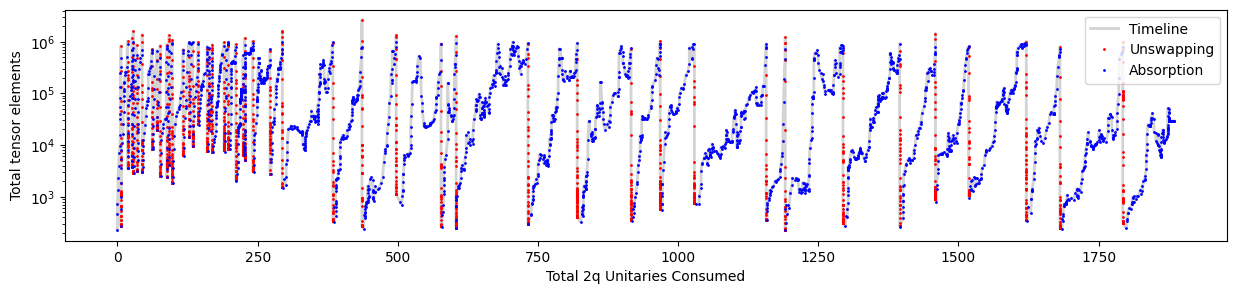

In [16]:
plt.plot(df["u_consumed_total"].values, df["total_elems"].values, '-',color='lightgray', linewidth=2.0)
plt.plot(df_unswap["u_consumed_total"].values, df_unswap["total_elems"].values, '.r', markersize=2)
plt.plot(df_absorb["u_consumed_total"].values, df_absorb["total_elems"].values, '.b', markersize=2)

plt.semilogy()
plt.xlabel("Total 2q Unitaries Consumed")
plt.ylabel("Total tensor elements")
plt.gcf().set_size_inches(15,3)
plt.legend(["Timeline", "Unswapping", "Absorption"])

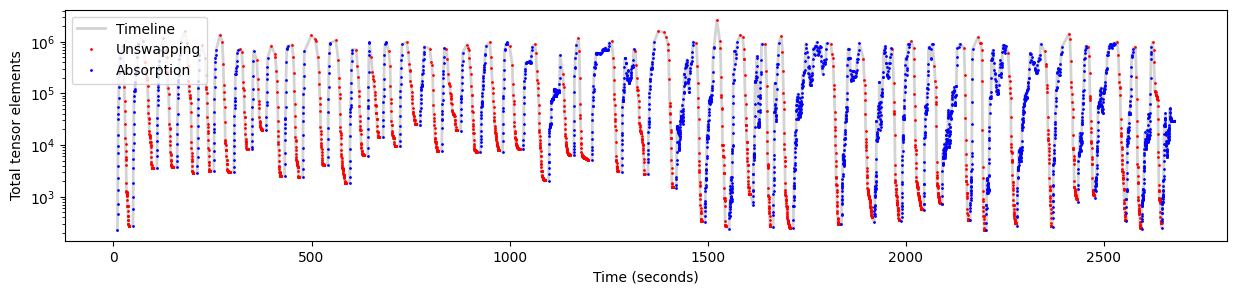

In [17]:
plt.plot(df["time"].values, df["total_elems"].values, '-',color='lightgray', linewidth=2.0)
plt.plot(df_unswap["time"].values, df_unswap["total_elems"].values, '.r', markersize=2)
plt.plot(df_absorb["time"].values, df_absorb["total_elems"].values, '.b', markersize=2)

plt.semilogy()
plt.xlabel("Time (seconds)")
plt.ylabel("Total tensor elements")
plt.gcf().set_size_inches(15,3)
plt.legend(["Timeline", "Unswapping", "Absorption"])

In [18]:
total_time = time.perf_counter() - t0
print(f"Total time: {total_time:.2f}s")

Total time: 2721.90s
